In [85]:
# !pip install the_well[benchmark]

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from einops import rearrange
from tqdm import tqdm
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

from the_well.benchmark.metrics import VRMSE
from the_well.data import WellDataset
from the_well.benchmark.models.unet_convnext import UNetConvNext

device = "cuda"
base_path = "./datasets"  # path/to/storage

## Learning curve

In [86]:
df_loss_phys = pd.read_csv("6_4_loss_UNetConvNext_physics.csv", sep=',')

print(df_loss_phys['Epochs'].shape)
print(df_loss_phys['mse_train'].shape)
print(df_loss_phys['loss_physics_train'].shape)
print(df_loss_phys['mse_valid'].shape)
print(df_loss_phys['loss_physics_valid'].shape)

(15,)
(15,)
(15,)
(15,)
(15,)


In [87]:
print(df_loss_phys)

    Unnamed: 0  Epochs  mse_train  loss_physics_train  total_train  mse_valid  \
0            0     0.0      0.624                4.04         4.66      0.513   
1            1     1.0      0.566                2.31         2.88      0.495   
2            2     2.0      0.556                2.20         2.76      0.490   
3            3     3.0      0.548                2.12         2.67      0.500   
4            4     4.0      0.546                2.09         2.64      0.487   
5            5     5.0      0.543                2.00         2.54      0.474   
6            6     6.0      0.536                1.77         2.30      0.482   
7            7     7.0      0.530                1.49         2.02      0.478   
8            8     8.0      0.528                1.19         1.71      0.477   
9            9     9.0      0.527                1.02         1.54      0.477   
10          10    10.0      0.528                1.00         1.53      0.478   
11          11    11.0      

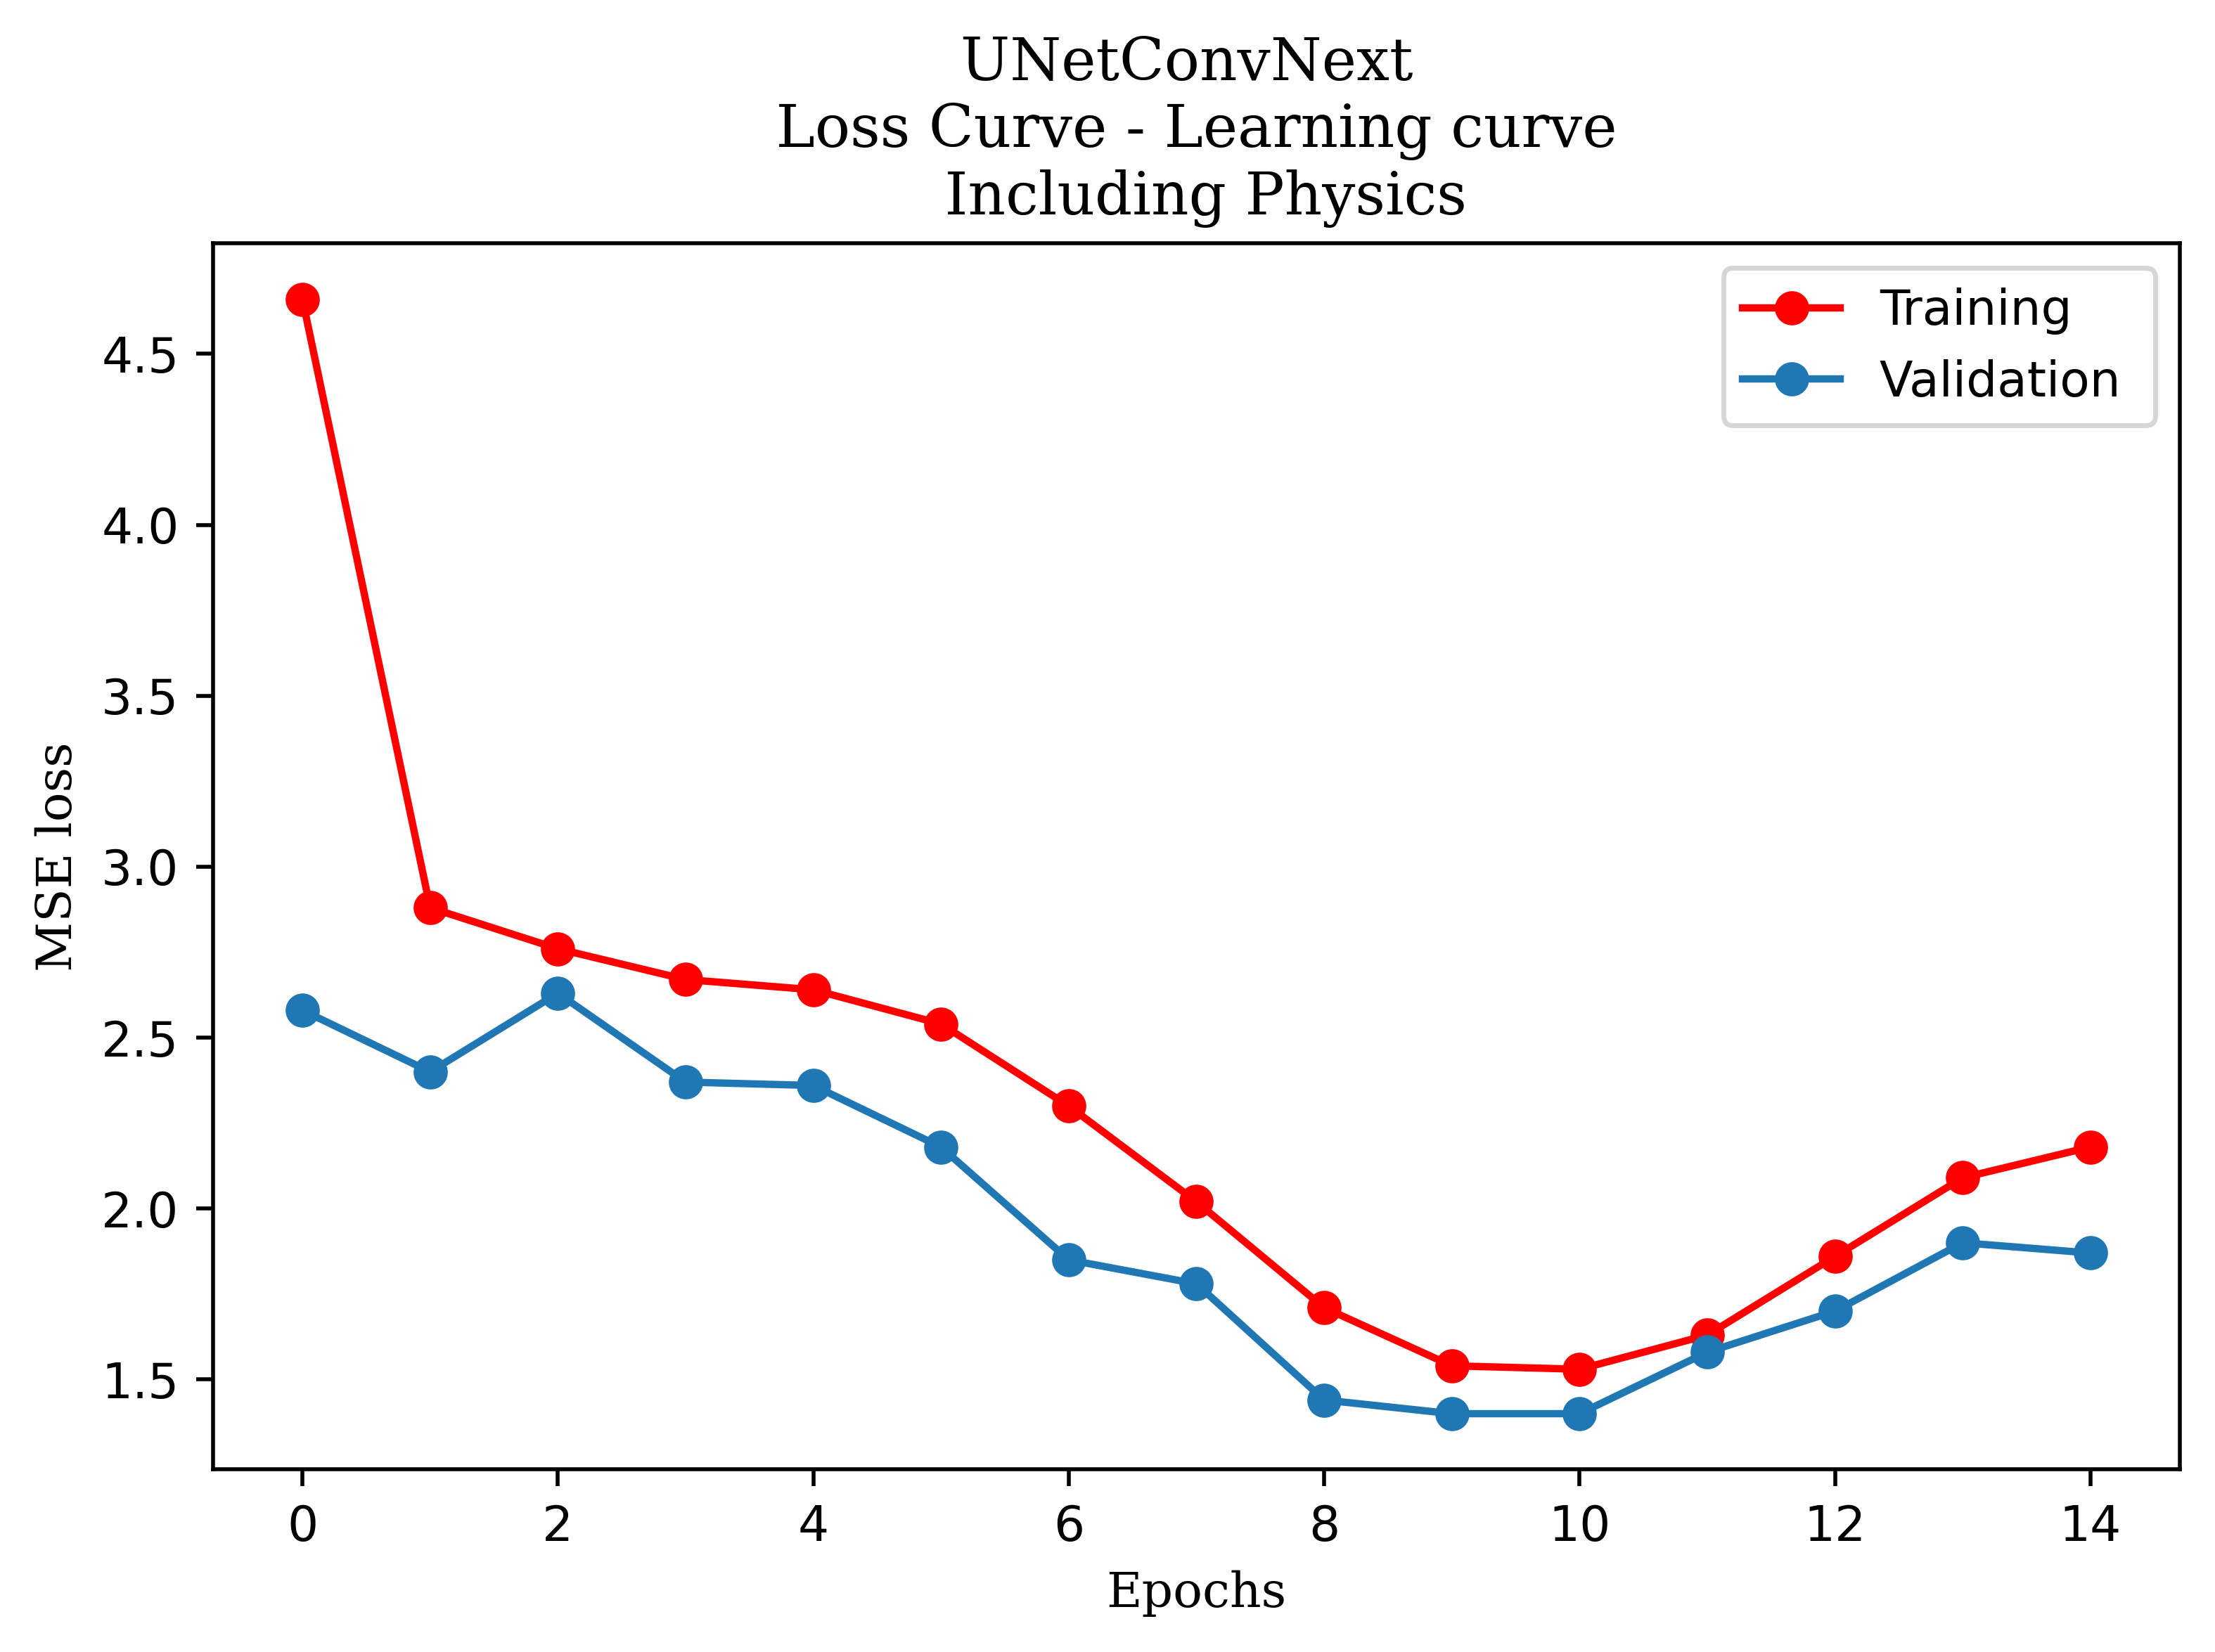

In [88]:
plt.figure(dpi=500)
plt.plot(df_loss_phys['Epochs'], df_loss_phys['total_train'], marker = 'o', ls = '-', color = 'red', label = 'Training')
plt.plot(df_loss_phys['Epochs'], df_loss_phys['total_valid'], marker = 'o', ls = '-', label = 'Validation ')
plt.xlabel('Epochs', family = 'serif')
plt.ylabel('MSE loss', family = 'serif')
plt.legend()
plt.title(f'UNetConvNext \n Loss Curve - Learning curve \n Including Physics', family = 'serif')
plt.tight_layout()
plt.savefig(f'6_5_Learning_curve_works_Physics_size.png', bbox_inches='tight')
plt.show()

## Testing

In [89]:
# Load the dataset
dataset_test = WellDataset(
    well_base_path = f'{base_path}/datasets',
    well_dataset_name = 'active_matter',
    well_split_name = "test",
    n_steps_input = 4,
    n_steps_output = 1,
    use_normalization = False
)

In [90]:
# Extract the number of fields
F = dataset_test.metadata.n_fields
print(F)

11


In [91]:
# Remember the key associated to each field
field_names_tmp = dataset_test.field_names

field_names_tmp2 = [
    name for group in field_names_tmp.values() for name in group
]

field_names = {}

for id in range(len(field_names_tmp2)):
    field_names[id] = field_names_tmp2[id]

print(field_names)

{0: 'concentration', 1: 'velocity_x', 2: 'velocity_y', 3: 'D_xx', 4: 'D_xy', 5: 'D_yx', 6: 'D_yy', 7: 'E_xx', 8: 'E_xy', 9: 'E_yx', 10: 'E_yy'}


In [92]:
norm_params = torch.load('./model_stats/normalisation_train_param.pt')
mu = norm_params['mu']
sigma = norm_params['sigma']

In [93]:
def preprocess(x):
    return (x - mu) / sigma


def postprocess(x):
    return sigma * x + mu

In [94]:
class CNextbaseline(nn.Module):
    def __init__(self,
                 in_channels: int,
                 out_channels: int,
                 initial_dimension: int,
                 up_down_blocks: int,
                 blocks_per_stage: int,
                 bottleneck_blocks: int,
                 spatial_resolution: tuple,
                 spatial_dims: int=2):
        
        super().__init__()
        
        self.model = UNetConvNext(
            dim_in = in_channels,
            dim_out = out_channels,
            n_spatial_dims = spatial_dims,
            spatial_resolution = spatial_resolution,
            stages = up_down_blocks,
            blocks_per_stage = blocks_per_stage,
            blocks_at_neck = bottleneck_blocks,
            init_features = initial_dimension 
        )
    
    def forward(self, x):
        return self.model(x)

In [95]:
# Set the model
model_cnet = CNextbaseline(in_channels=4*F,
                           out_channels=1*F,
                           initial_dimension=42,
                           blocks_per_stage=2,
                           up_down_blocks=4,
                           bottleneck_blocks=1,
                           spatial_resolution=(256,256)).to(device)


model_cnet_phys = CNextbaseline(in_channels=4*F,
                           out_channels=1*F,
                           initial_dimension=42,
                           blocks_per_stage=2,
                           up_down_blocks=4,
                           bottleneck_blocks=1,
                           spatial_resolution=(256,256)).to(device)

In [96]:
# Load the weights into the model
stats = torch.load("./model_UNetConvNext_stats/trained_UNetConvNext_epoch_9.pth")
model_cnet.load_state_dict(stats)

stats_phys = torch.load("./model_UNetConvNext_phys_stats/trained_UNetConvNext_phys_epoch_9.pth")
#stats_phys = torch.load("./model_stats/model_UNetConvNext_physics.pth")
model_cnet_phys.load_state_dict(stats_phys)

<All keys matched successfully>

In [97]:
item_id = 1000
model_cnet.eval()
snap_in= dataset_test[item_id]["input_fields"]
ground_truth= dataset_test[item_id]["output_fields"]

model_cnet_phys.eval()
snap_in= dataset_test[item_id]["input_fields"]
ground_truth= dataset_test[item_id]["output_fields"]

In [98]:
# Normalise the input
snap_in = snap_in.to(device)
snap_in = preprocess(snap_in)
snap_in = rearrange(snap_in, "Ti Lx Ly F -> 1 (Ti F) Lx Ly")

In [99]:
prediction = model_cnet(snap_in)
prediction = rearrange(prediction, "1 (To F) Lx Ly -> To Lx Ly F", F=11)
prediction = postprocess(prediction)

prediction_phys = model_cnet_phys(snap_in)
prediction_phys = rearrange(prediction_phys, "1 (To F) Lx Ly -> To Lx Ly F", F=11)
prediction_phys = postprocess(prediction_phys)

In [100]:
# De-normalise input
snap_in = rearrange(snap_in, "1 (Ti F) Lx Ly -> Ti Lx Ly F", F=11)
snap_in = postprocess(snap_in)

snap_in = snap_in.detach()
snap_in = snap_in.to('cpu')

In [101]:
# Move prediction from cuda to cpu
prediction = prediction.detach()
prediction = prediction.to('cpu')

prediction_phys = prediction_phys.detach()
prediction_phys = prediction_phys.to('cpu')

In [102]:
f_id = 9
n_in = snap_in[:,:,:,f_id].shape[0]
n_out = ground_truth[:,:,:,f_id].shape[0]

In [103]:
print(snap_in[:,:,:,f_id].shape)

torch.Size([4, 256, 256])


In [104]:
# minima = torch.min(ground_truth[:,:,:,f_id]).detach().item() 
# maxima = torch.max(ground_truth[:,:,:,f_id]).detach().item()
# print(minima, maxima)

In [105]:
minima = -1.3921607732772827
maxima = 1.5173805952072144

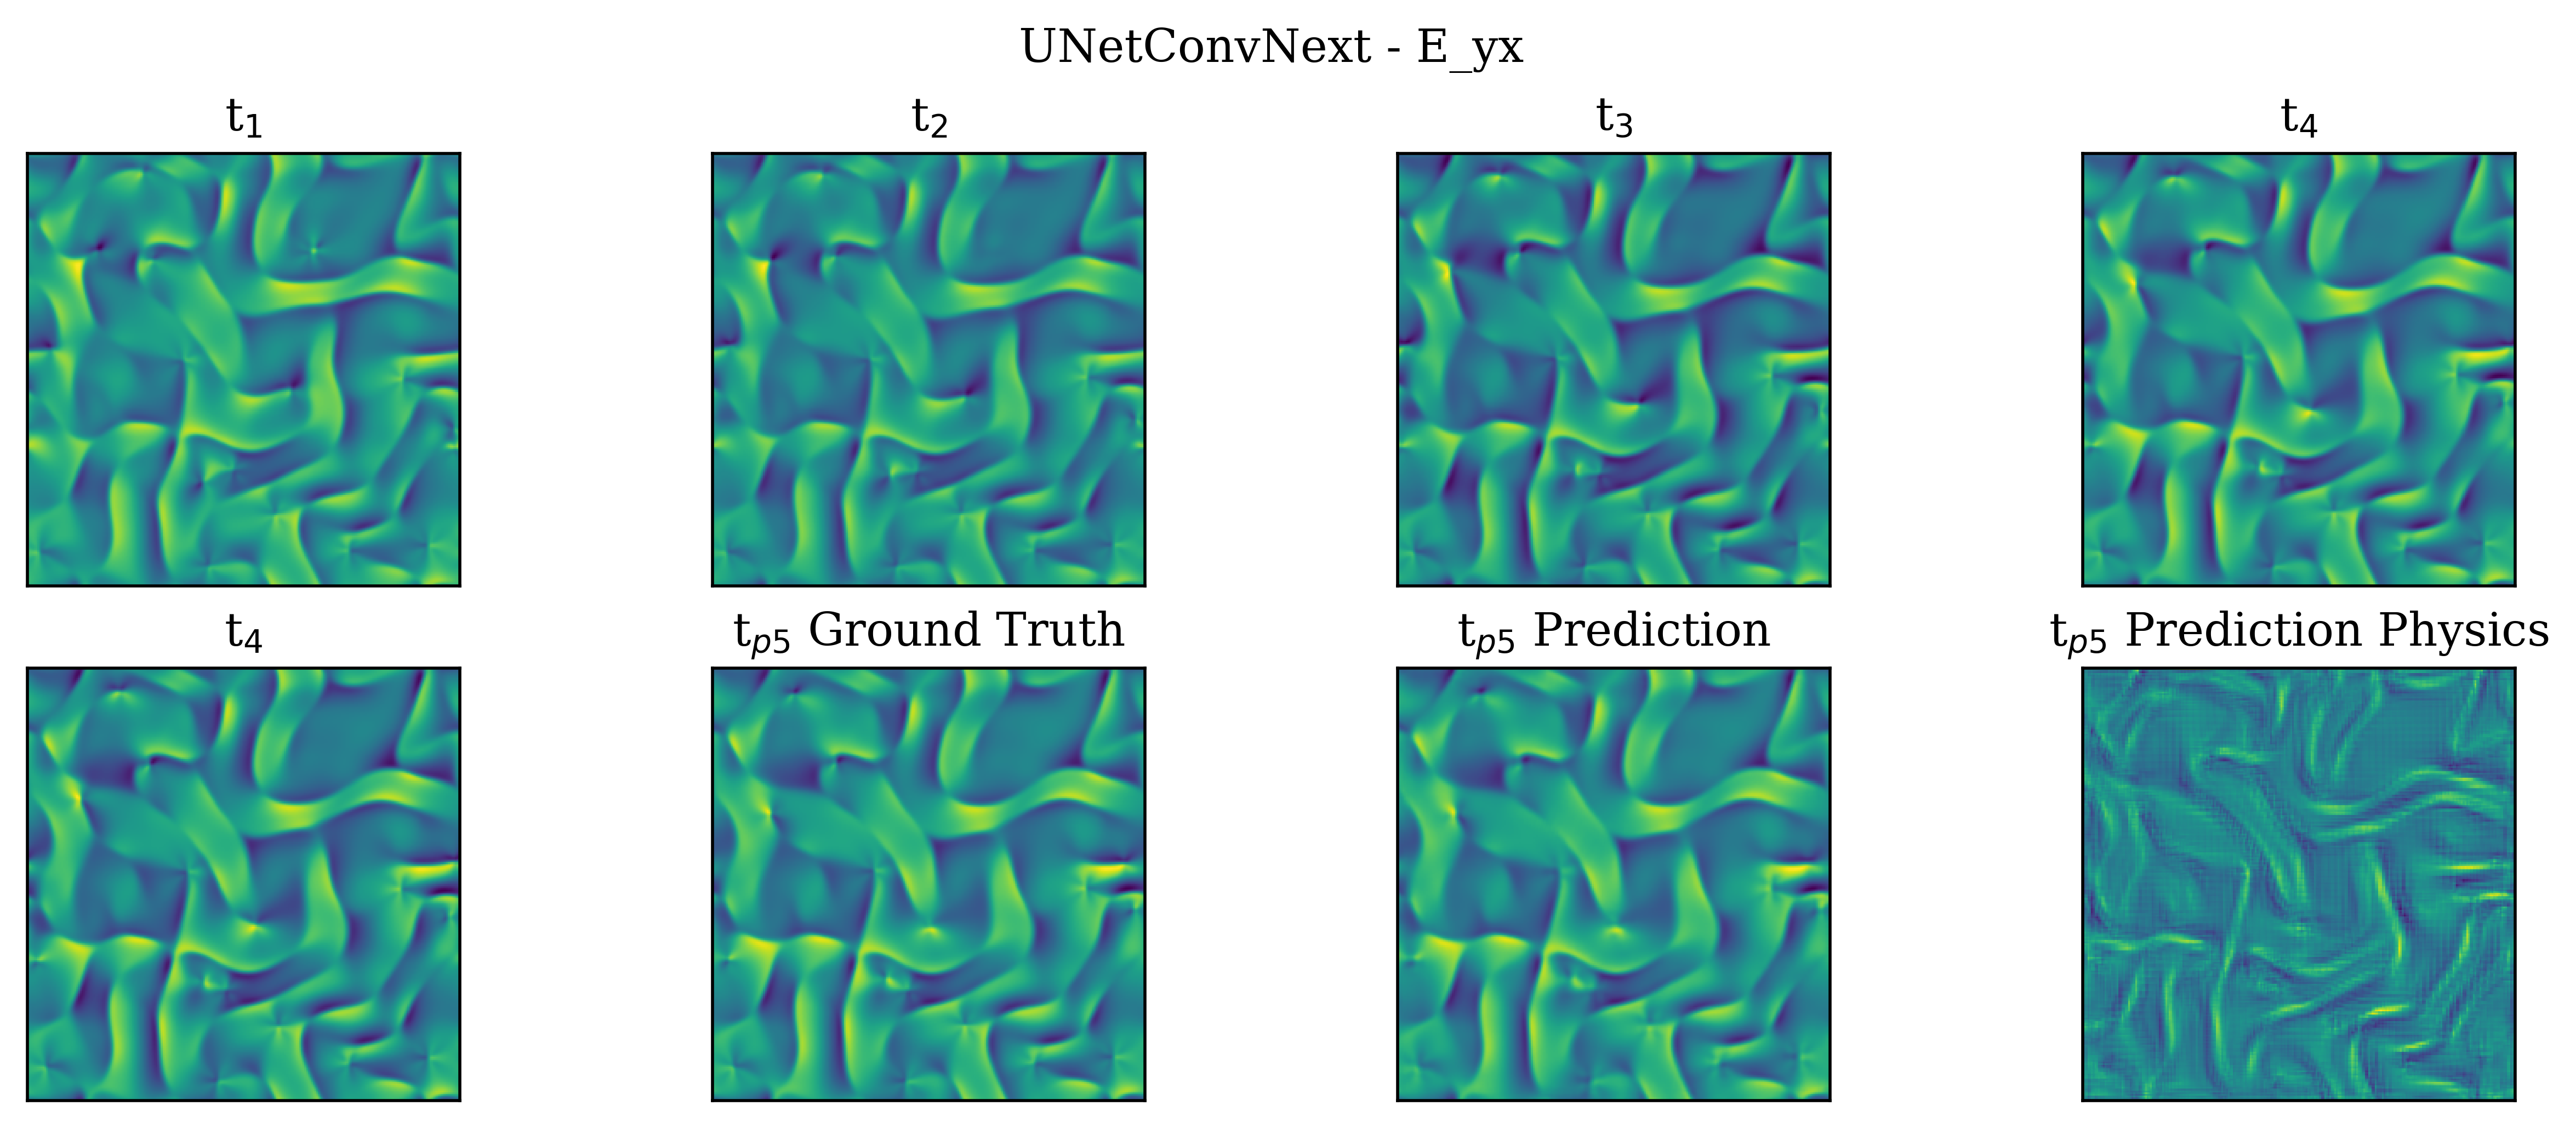

In [106]:
fig, axs = plt.subplots(
    nrows=2, 
    ncols=4, 
    figsize=(10, 4),
    dpi = 500,
    sharex=True, 
    sharey=True,
    constrained_layout=True
)

#fig, axs = plt.subplots(1, 3, figsize = (10, 4), dpi = 500)

axs[0,0].imshow(snap_in[0,:,:,f_id]) #, vmin = minima, vmax = maxima)   
axs[0,0].set_xticks([])
axs[0,0].set_yticks([])
axs[0,0].set_title(r"t$_1$", family = 'serif')

axs[0,1].imshow(snap_in[1,:,:,f_id]) #, vmin = minima, vmax = maxima)   
axs[0,1].set_xticks([])
axs[0,1].set_yticks([])
axs[0,1].set_title(r"t$_2$", family = 'serif')

axs[0,2].imshow(snap_in[2,:,:,f_id]) #, vmin = minima, vmax = maxima)   
axs[0,2].set_xticks([])
axs[0,2].set_yticks([])
axs[0,2].set_title(r"t$_3$", family = 'serif')

axs[0,3].imshow(snap_in[3,:,:,f_id]) #, vmin = minima, vmax = maxima)   
axs[0,3].set_xticks([])
axs[0,3].set_yticks([])
axs[0,3].set_title(r"t$_4$", family = 'serif')

axs[1,0].imshow(snap_in[3,:,:,f_id]) #, vmin = minima, vmax = maxima)   
axs[1,0].set_xticks([])
axs[1,0].set_yticks([])
axs[1,0].set_title(r"t$_4$", family = 'serif')

cmap1 = axs[1,1].imshow(ground_truth[0,:,:,f_id]) #, vmin = minima, vmax = maxima)   
axs[1,1].set_xticks([])
axs[1,1].set_yticks([])
axs[1,1].set_title(r"t$_{p5}$ Ground Truth", family = 'serif')
#fig.colorbar(cmap1, ax=axs[0])

cmap2 = axs[1,2].imshow(prediction[0, :, :, f_id]) #, vmin = minima, vmax = maxima)
axs[1,2].set_xticks([])
axs[1,2].set_yticks([])
axs[1,2].set_title(r"t$_{p5}$ Prediction", family = 'serif')
#fig.colorbar(cmap2, ax=axs[1])

cmap3 = axs[1,3].imshow(prediction_phys[0, :, :, f_id] )#, vmin = minima, vmax = maxima)
axs[1,3].set_xticks([])
axs[1,3].set_yticks([])
axs[1,3].set_title(r"t$_{p5}$ Prediction Physics", family = 'serif')
#fig.colorbar(cmap3, ax=axs[2])

# # Add a colorbar with a label
# cbar = fig.colorbar(cmap1, ax=axs.ravel().tolist(), shrink=0.8, format="%.2f")
# cbar.set_label("Concentration", rotation=270, labelpad=20)


plt.suptitle(f"UNetConvNext - {field_names[f_id]}", family = 'serif')
#plt.tight_layout()
plt.savefig("6_5_Testing_UNetConvNext_physics.png", bbox_inches='tight')
plt.show()

In [107]:
def partials_velocities(prediction_batch):
    ''' 
    Takes the tensor of the shape B (To F) Lx Ly 
    and returns the tensor associated to the dvx/dy, dvx/dx and
    dvy/dy, dvy/dx components.
    '''
    # Choose the vx and vy components
    vx_id = [k for k, v in field_names.items() if v=='velocity_x']
    vy_id = [k for k, v in field_names.items() if v=='velocity_y']

    dvxdy_list = [] 
    dvxdx_list = []
    dvydy_list = [] 
    dvydx_list = []

    for id in range(prediction_batch.shape[0]):
        pred_sample_tmp = prediction_batch[id]

        vx_sample = pred_sample_tmp[vx_id[0]]
        vy_sample = pred_sample_tmp[vy_id[0]]

        # Spatial gradients
        dvxdy_tmp, dvxdx_tmp = torch.gradient(vx_sample)
        dvydy_tmp, dvydx_tmp = torch.gradient(vy_sample)

        dvxdy_list.append(dvxdy_tmp)
        dvxdx_list.append(dvxdx_tmp)
        dvydy_list.append(dvydy_tmp)
        dvydx_list.append(dvydx_tmp)
    
    return torch.stack(dvxdx_list, dim = 0), torch.stack(dvxdy_list, dim = 0), torch.stack(dvydx_list, dim = 0), torch.stack(dvydy_list, dim = 0) 

In [108]:
# Spatial gradients
dvxdy, dvxdx = torch.gradient(ground_truth[0,:,:,1])
dvydy, dvydx = torch.gradient(ground_truth[0,:,:,2])

div = dvxdx + dvydy

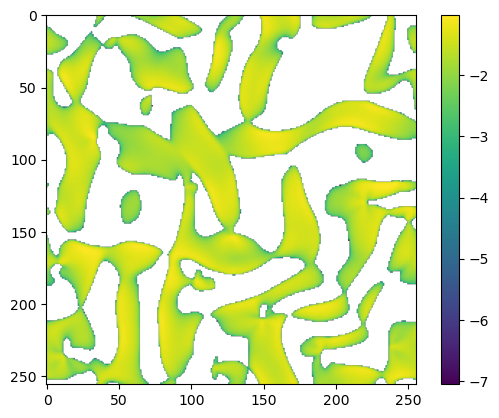

In [109]:
fig, ax = plt.subplots()
cmap = ax.imshow(torch.log10(div))
plt.colorbar(cmap)

In [110]:
# Spatial gradients
dvxdy_p, dvxdx_p = torch.gradient(prediction_phys[0,:,:,1])
dvydy_p, dvydx_p = torch.gradient(prediction_phys[0,:,:,2])

div_p = dvxdx_p + dvydy_p

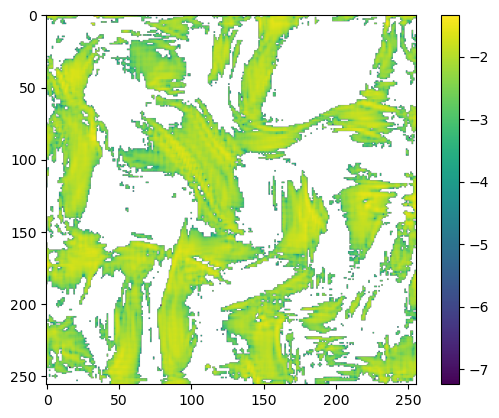

In [111]:
fig, ax = plt.subplots()
cmap = ax.imshow(torch.log10(div_p))
plt.colorbar(cmap)